# Import Libraries

In [136]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.impute import KNNImputer

# Load Dataset

In [137]:
df = pd.read_csv('/content/Dataset for Data Analytics - Sheet1.csv')
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [139]:
df.shape

(1200, 14)

# Missing Value Analysis

In [140]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


# Handle Missing Values

In [141]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [142]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


# Convert Date Column

In [143]:
df["Date"] = pd.to_datetime(df["Date"])

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

#Extract Useful Date Features

In [145]:
#Order Month
df["OrderMonth"] = df["Date"].dt.month

In [146]:
#Order Year
df["OrderYear"] = df["Date"].dt.year

In [147]:
#Order Quarter
df["OrderQuarter"] = df["Date"].dt.quarter

# Verify TotalPrice

In [148]:
df["CheckPrice"] = df["Quantity"] * df["UnitPrice"]

In [149]:
(df["CheckPrice"] == df["TotalPrice"]).sum()

np.int64(1066)

In [150]:
df.drop("CheckPrice",axis=1,inplace=True)

# Univariate EDA

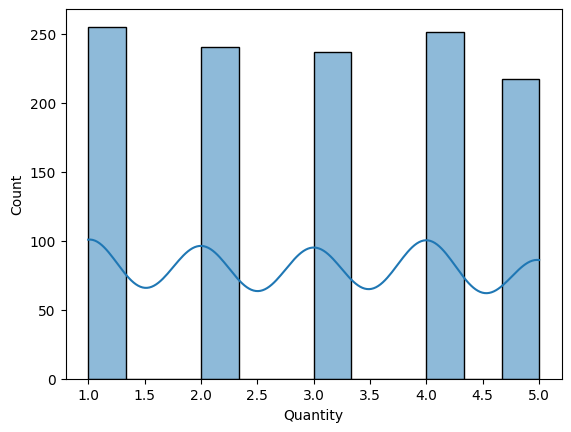

In [151]:
#Quantity Distribution
sns.histplot(df["Quantity"],kde=True)
plt.show()


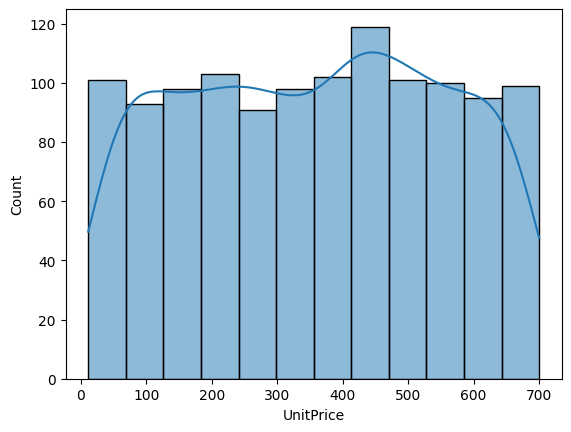

In [152]:
#UnitPrice Distribution
sns.histplot(df["UnitPrice"],kde=True)
plt.show()

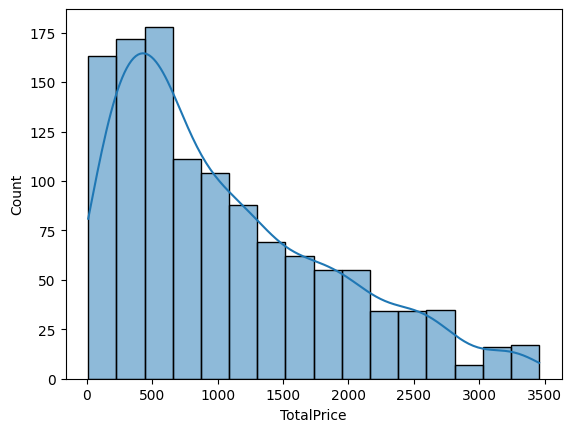

In [153]:
#TotalPrice Distribution
sns.histplot(df["TotalPrice"],kde=True)
plt.show()

# Categorical Analysis

In [154]:
#Product Count
df["Product"].value_counts()

,count
Product,
Printer,181
Tablet,179
Chair,178
Laptop,173
Desk,170
Monitor,163
Phone,156


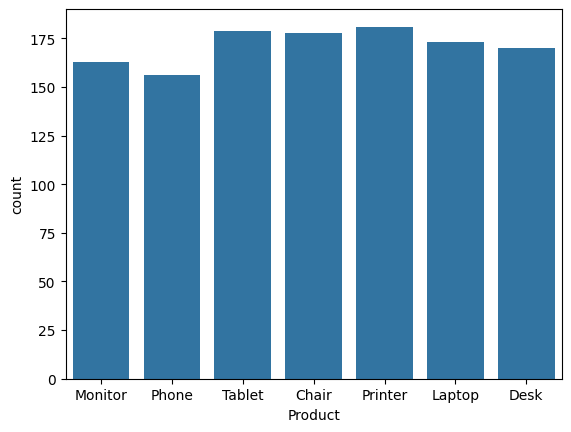

In [155]:
sns.countplot(x=df["Product"])
plt.show()

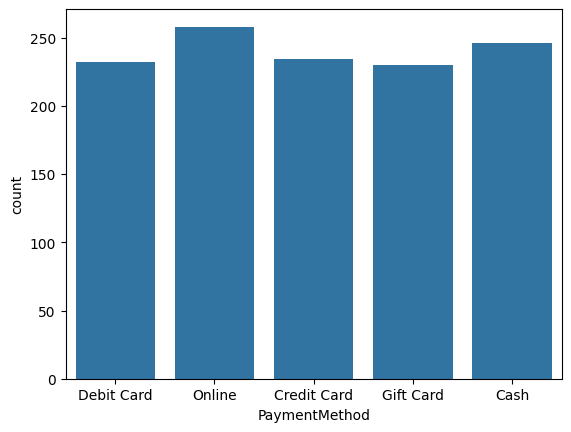

In [156]:
#Payment Method
sns.countplot(x=df["PaymentMethod"])
plt.show()

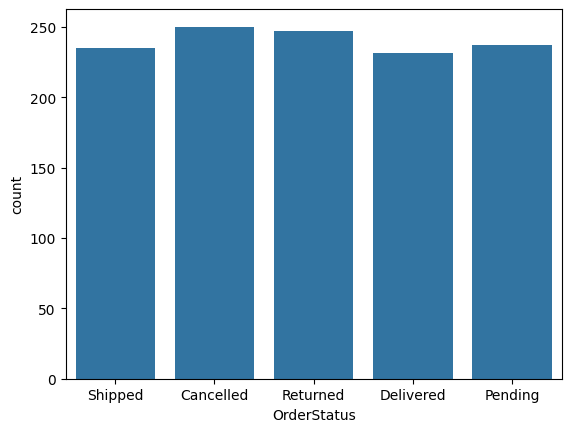

In [157]:
#Order Status
sns.countplot(x=df["OrderStatus"])
plt.show()

# Outlier Detection

In [158]:
#Quantity
Q1 = df["Quantity"].quantile(0.25)
Q3 = df["Quantity"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [159]:
outliers = df[
    (df["Quantity"] < lower) |
    (df["Quantity"] > upper)
]


In [160]:
#UnitPrice
Q1 = df["UnitPrice"].quantile(0.25)
Q3 = df["UnitPrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [161]:
outliers = df[
    (df["UnitPrice"] < lower) |
    (df["UnitPrice"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 0


In [162]:
#TotalPrice
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [163]:
outliers = df[
    (df["TotalPrice"] < lower) |
    (df["TotalPrice"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 8


# Outlier Treatment

In [164]:
#Capping
df["UnitPrice"] = np.clip(
    df["UnitPrice"],
    lower,
    upper
)

In [165]:
df["Quantity"] = np.clip(
    df["Quantity"],
    lower,
    upper
)

In [166]:
df["TotalPrice"] = np.clip(
    df["TotalPrice"],
    lower,
    upper
)

# Feature Engineering

In [167]:
#Average Item Value
df["AvgItemValue"] = (
    df["TotalPrice"] / df["Quantity"]
)

In [168]:
#Discount Applied
df["DiscountApplied"] = np.where(
    df["CouponCode"] == "No Coupon",
    0,
    1
)

In [169]:
#Basket Value
df["BasketValue"] = (
    df["TotalPrice"] /
    df["ItemsInCart"]
)

In [170]:
#High Value Order
avg_price = df["TotalPrice"].mean()

df["HighValueOrder"] = np.where(
    df["TotalPrice"] > avg_price,
    1,
    0
)

In [171]:
#Items Per Quantity Ratio
df["CartRatio"] = (
    df["ItemsInCart"] /
    df["Quantity"]
)

# Correlation Analysis

In [172]:
numeric_df = df.select_dtypes(
    include=np.number
)

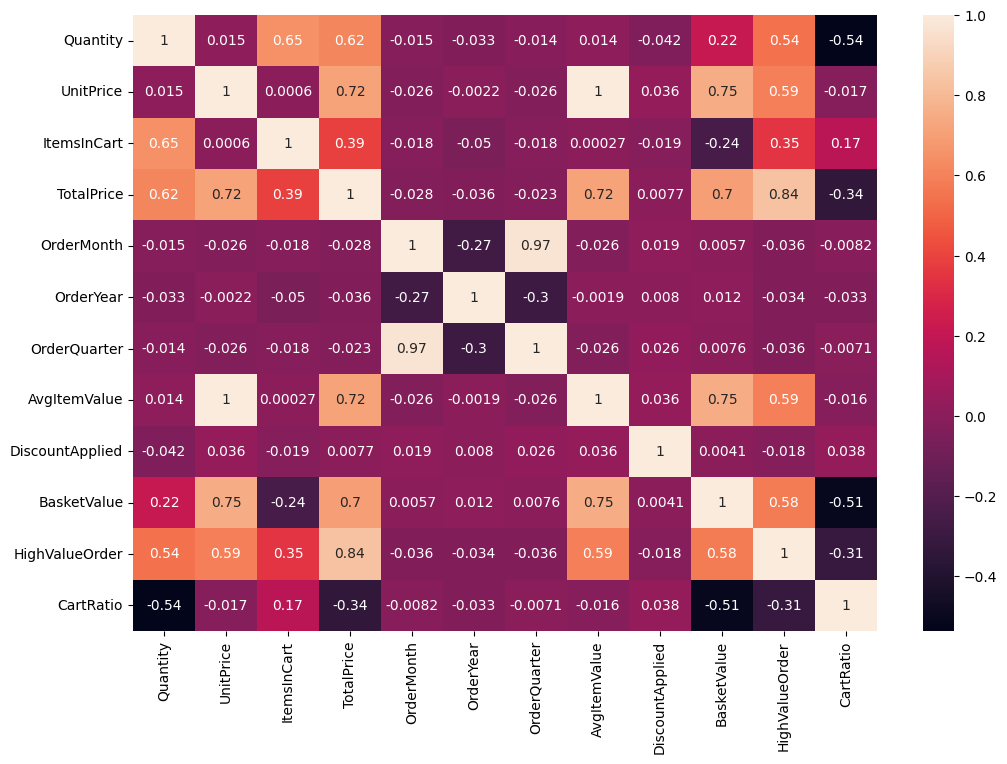

In [173]:
plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True
)
plt.show()

# Encoding


In [174]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "Product",
        "PaymentMethod",
        "OrderStatus",
        "ReferralSource"
    ],
    drop_first=True
)

In [175]:
df.to_csv(
    "cleaned_dataset.csv",
    index=False
)